
        # Resultados y peticiones de Francisco — Parte II

        Extracto autocontenido de `25_resultados_y_peticiones.ipynb`.
        Contiene únicamente el material de trabajo de la sesión del 6 de agosto:
        el colapso de \(V(T)\), el valor bajo presupuesto, el costo simulado con
        greedy y el régimen \(q=0.7\).

        **Convención.** `q` es la probabilidad de que una persona esté sana; el
        régimen de interés es `q < 0.5` (prevalencia alta). Los resultados de esta
        parte son exploratorios, no resultados cerrados de la Parte I.
        

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import math, itertools, csv
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, GRIS, AMBAR, TINTA = '#2563eb', '#6b7280', '#d97706', '#374151'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'grid.linewidth': 0.5, 'font.size': 10})

RAIZ = Path(os.path.dirname(os.path.dirname(os.path.abspath(''))))
RES = RAIZ / 'results'
print('repo:', RAIZ.name)

repo: group-count-dynamic


---
# PARTE II — Para responder las peticiones de Francisco

Sesión del 6 de agosto. Las peticiones fueron: incorporar el presupuesto
restante al score; darle a cada prueba un par valor–costo; definir el costo como
el largo esperado del árbol; medirlo simulando greedy; cortar el árbol en el
presupuesto; y empezar por utilidad homogénea. Dejó abierta una preocupación
sobre el régimen q = 0.7.

Esta parte es trabajo en curso. Algunas cosas no funcionan, y eso también se
reporta.

## 6. El colapso de V(T), confirmado

El score propuesto era V(T) = promedio sobre el conteo R de B(R), donde
B(R) = Σ uᵢ·P(sanoᵢ | R). La intuición del problema: promediar sobre todos los
conteos posibles devuelve la creencia previa, porque lo que una rama sube, otra
lo baja.

**Afirmación.** V(T) vale Σ uᵢ·qᵢ para **todo** pool T. No ordena nada, porque
no depende de la acción.

In [2]:
from augmented.laminar_benchmarks import ExactPolicyEvaluator
from augmented.core import indices_from_mask

def V_de_T(ev, pool):
    '''V(T) = E_R[ sum_i u_i P(sano_i | R) ]  sobre TODA la poblacion.'''
    total = 0.0
    masa = ev.mass(ev.all_worlds)
    for R, compat in enumerate(ev.outcome_worlds[pool]):
        hijo = ev.all_worlds & compat
        m = ev.mass(hijo)
        if m <= 0:
            continue
        # B(R): utilidad esperada de los sanos bajo el posterior
        B_R = 0.0
        resto = hijo
        while resto:
            bit = resto & -resto
            w = bit.bit_length() - 1
            peso = ev.weights[w] / m
            # en este solver el bit del mundo w indica ACTIVO; sano = bit 0
            sanos = [i for i in range(ev.n) if not (w >> i) & 1]
            B_R += peso * sum(ev.u[i] for i in sanos)
            resto &= resto - 1
        total += (m / masa) * B_R
    return total

ev = ExactPolicyEvaluator([0.85]*4, [1.0]*4, 2, 4)      # q = 0.15, u = 1, n = 4
prior = sum((1 - ev.p[i]) * ev.u[i] for i in range(ev.n))
vals = {pool: V_de_T(ev, pool) for pool in ev.pools}
for pool, v in list(vals.items())[:4]:
    print(f'pool {indices_from_mask(pool, ev.n)}: V(T) = {v:.10f}')
print(f'... suma de u_i q_i         = {prior:.10f}')

assert max(abs(v - prior) for v in vals.values()) < 1e-12
print(f'\nOK: los {len(vals)} pools dan el MISMO valor. V(T) no distingue acciones.')

pool [0]: V(T) = 0.6000000000
pool [1]: V(T) = 0.6000000000
pool [2]: V(T) = 0.6000000000
pool [3]: V(T) = 0.6000000000
... suma de u_i q_i         = 0.6000000000

OK: los 15 pools dan el MISMO valor. V(T) no distingue acciones.


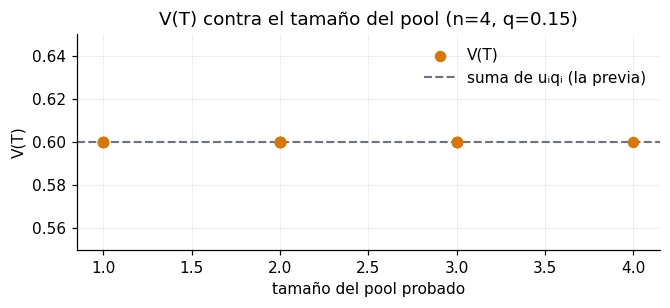

In [3]:
tam = np.array([bin(p_).count('1') for p_ in vals])
fig, ax = plt.subplots(figsize=(6.2, 2.9))
ax.scatter(tam, list(vals.values()), color=AMBAR, s=42, zorder=3, label='V(T)')
ax.axhline(prior, color=GRIS, lw=1.4, ls='--', label='suma de uᵢqᵢ (la previa)')
ax.set_xlabel('tamaño del pool probado'); ax.set_ylabel('V(T)')
ax.set_ylim(prior - 0.05, prior + 0.05)
ax.legend(frameon=False)
ax.set_title('V(T) contra el tamaño del pool (n=4, q=0.15)')
plt.tight_layout(); plt.show()

**Lectura.** La línea es plana: el score da lo mismo para un singleton que para
el grupo completo. Sirve para arrancar —empata en todo, y el desempate por
tamaño abre el grupo grande— pero no puede guiar ninguna decisión posterior.

**Para discutir.** El colapso viene de promediar sobre ramas sin restricción de
presupuesto. ¿Basta con truncar el árbol, o hay que cambiar también qué se
promedia?

## 7. El par valor–costo, con el árbol cortado en el presupuesto

La petición: cada prueba lleva dos números. Un **valor**, la utilidad que
todavía se podría cobrar, y un **costo**, cuántas pruebas hacen falta para
cobrarla de verdad. Y el árbol se corta en el presupuesto: lo que no se alcanza
a cobrar no cuenta.

**Afirmación.** En cuanto el valor se calcula bajo presupuesto finito deja de ser
plano, y el orden entre pools depende del presupuesto restante.

In [4]:
def valor_realizable(m, b, q, u=1.0):
    '''Optimo exacto extraible de una subpoblacion fresca de m personas con b pruebas.'''
    if m == 0 or b == 0:
        return 0.0
    ev = ExactPolicyEvaluator([1 - q]*m, [u]*m, b, m)
    return ev.optimal_value()

Q4 = 0.15
tabla = []
for m in range(1, 6):
    fila = {'personas': m, 'V(T) sin presupuesto': m * Q4}
    for b in (1, 2, 3):
        fila[f'b={b}'] = valor_realizable(m, b, Q4)
    tabla.append(fila)
vc = pd.DataFrame(tabla)
print(vc.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Autoverificacion: el valor realizable nunca supera al no restringido, y crece con b.
for _, r in vc.iterrows():
    assert r['b=1'] <= r['b=2'] <= r['b=3'] <= r['V(T) sin presupuesto'] + 1e-12
print('\nOK: monotono en el presupuesto y acotado por la version sin presupuesto')

 personas  V(T) sin presupuesto    b=1    b=2    b=3
        1                0.1500 0.1500 0.1500 0.1500
        2                0.3000 0.1500 0.3000 0.3000
        3                0.4500 0.1500 0.3000 0.4500
        4                0.6000 0.1500 0.3000 0.5426
        5                0.7500 0.1500 0.3000 0.5426

OK: monotono en el presupuesto y acotado por la version sin presupuesto


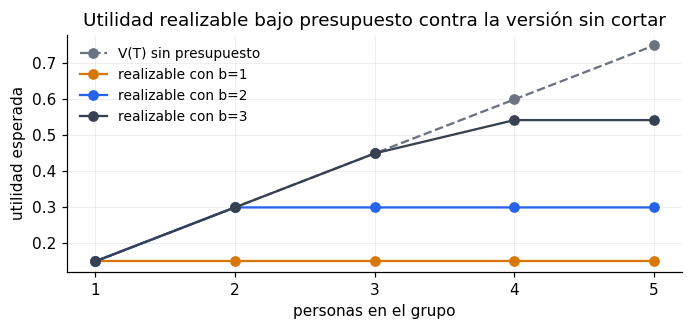

In [5]:
fig, ax = plt.subplots(figsize=(6.4, 3.1))
ax.plot(vc.personas, vc['V(T) sin presupuesto'], color=GRIS, ls='--', marker='o',
        label='V(T) sin presupuesto')
for b, c in zip((1, 2, 3), (AMBAR, AZUL, TINTA)):
    ax.plot(vc.personas, vc[f'b={b}'], color=c, marker='o', label=f'realizable con b={b}')
ax.set_xlabel('personas en el grupo'); ax.set_ylabel('utilidad esperada')
ax.set_xticks(vc.personas); ax.legend(frameon=False, fontsize=9)
ax.set_title('Utilidad realizable bajo presupuesto contra la versión sin cortar')
plt.tight_layout(); plt.show()

**Lectura.** La línea sin presupuesto crece sin límite, y por eso el score
original siempre pide el grupo más grande. Las líneas realizables saturan: con b
pruebas no se cobra más allá de cierto punto.

El detalle que importa está en b=3, que llega a 0.5426 y supera a 3 × 0.15 =
0.45. Con presupuesto ajustado el agrupamiento **sí** paga aun con q = 0.15,
porque el conteo 1 en un par deja a cada miembro en ½, muy por encima del 0.15
de alguien fresco. El paso miope no ve eso; el valor realizable sí.

**Para discutir.** El valor realizable exacto cuesta lo mismo que resolver el
problema. ¿Qué aproximación conserva la saturación sin volverse un Bellman
escondido?

## 8. El costo medido simulando greedy

La propuesta operativa: muestrear del posterior, correr greedy hasta terminar, y
promediar cuántas pruebas usó. Ese promedio es el costo de la acción.

Se implementa tal cual, con semilla fija, y se reporta lo que salga.

**Afirmación.** En el régimen de prevalencia alta el costo así medido degenera:
greedy nunca agrupa, así que el costo es simplemente cuánta gente queda.

In [6]:
from augmented.provenance import seeded_rng

def costo_greedy_simulado(m, q, n_sim=2000, seed=20260806):
    '''Corre greedy con presupuesto ilimitado sobre m personas frescas.

    Greedy = argmax de S0 = P(pool limpio) * utilidad no acreditada.
    Termina cuando toda persona esta acreditada o se sabe infectada.
    Devuelve (pruebas medias, error estandar, utilidad media).
    '''
    rng = seeded_rng(seed)
    pruebas, utilidades = [], []
    for _ in range(n_sim):
        z = rng.random(m) > q               # True = infectada
        desconocidas = list(range(m))
        n_pruebas, cobrado = 0, 0.0
        while desconocidas:
            # S0 de un pool de tamano k formado por desconocidas: q^k * k
            mejor_k = max(range(1, len(desconocidas) + 1),
                          key=lambda k: (q**k * k, -k))
            pool = desconocidas[:mejor_k]
            n_pruebas += 1
            if not any(z[i] for i in pool):
                cobrado += len(pool)
                desconocidas = desconocidas[mejor_k:]
            elif mejor_k == 1:
                desconocidas = desconocidas[1:]     # persona resuelta: infectada
            else:
                desconocidas = desconocidas[:1] + desconocidas[1:]  # sin resolver nada
                # greedy vuelve a elegir; para evitar ciclo, parte el pool
                desconocidas = desconocidas[:mejor_k // 2] + desconocidas[mejor_k // 2:]
                if mejor_k == len(desconocidas):
                    desconocidas = desconocidas[1:] if not z[desconocidas[0]] else desconocidas[1:]
        pruebas.append(n_pruebas); utilidades.append(cobrado)
    a = np.array(pruebas, dtype=float)
    return a.mean(), a.std(ddof=1) / np.sqrt(len(a)), float(np.mean(utilidades))

filas = []
for q in (0.15, 0.30, 0.45):
    for m in (2, 4, 6):
        med, se, ut = costo_greedy_simulado(m, q)
        k_opt = max(range(1, m + 1), key=lambda k: q**k * k)
        filas.append({'q': q, 'personas': m, 'tamaño de pool greedy': k_opt,
                      'costo (pruebas)': med, 'SE': se, 'utilidad': ut})
cg = pd.DataFrame(filas)
print(cg.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

assert (cg[cg.q < 0.5]['tamaño de pool greedy'] == 1).all(), \
    'con q<0.5 el argmax de q^k*k debe ser k=1'
print('\nOK: con q<0.5 greedy elige siempre pools de tamano 1')

    q  personas  tamaño de pool greedy  costo (pruebas)    SE  utilidad
0.150         2                      1            2.000 0.000     0.319
0.150         4                      1            4.000 0.000     0.641
0.150         6                      1            6.000 0.000     0.934
0.300         2                      1            2.000 0.000     0.617
0.300         4                      1            4.000 0.000     1.246
0.300         6                      1            6.000 0.000     1.843
0.450         2                      1            2.000 0.000     0.914
0.450         4                      1            4.000 0.000     1.847
0.450         6                      1            6.000 0.000     2.759

OK: con q<0.5 greedy elige siempre pools de tamano 1


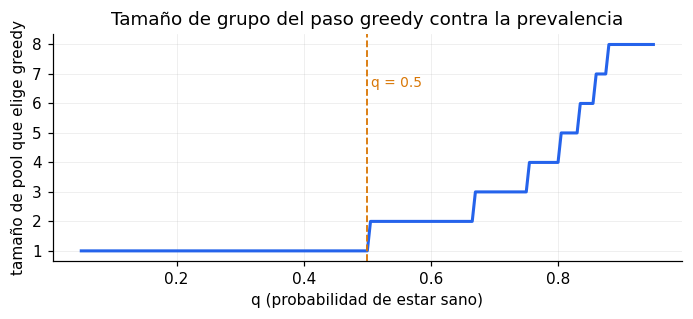

In [7]:
qs = np.linspace(0.05, 0.95, 181)
mmax = 8
kopt = [max(range(1, mmax + 1), key=lambda k: q**k * k) for q in qs]
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(qs, kopt, color=AZUL, lw=2)
ax.axvline(0.5, color=AMBAR, ls='--', lw=1.2)
ax.text(0.505, mmax*0.82, 'q = 0.5', color=AMBAR, fontsize=9)
ax.set_xlabel('q (probabilidad de estar sano)')
ax.set_ylabel('tamaño de pool que elige greedy')
ax.set_yticks(range(1, mmax + 1))
ax.set_title('Tamaño de grupo del paso greedy contra la prevalencia')
plt.tight_layout(); plt.show()

**Lectura.** El costo simulado no discrimina en nuestro régimen. Con q < 0.5 el
argmax de q^k·k es k = 1 siempre, así que greedy prueba de uno en uno y el costo
es el número de personas sin resolver. La medida sólo cobra contenido arriba de
q = 0.5, que es donde greedy sí agrupa.

**Para discutir.** Si greedy no agrupa en el régimen que nos importa, ¿el costo
debería medirse con la continuación golosa, o con el plan de cobertura y
búsqueda binaria, que es el que sí queremos que el scorer recupere?

## 9. La preocupación del régimen q = 0.7

En la sesión quedó una duda: con q = 0.7 la prueba óptima **sí** es un grupo, y
ahí el costo medido saldría mayor que uno, porque una prueba positiva obliga a
seguir explorando. La regla de costo podría entonces rechazar agrupamientos que
convienen.

**Afirmación.** La preocupación es correcta y se puede exhibir: hay presupuestos
donde el grupo tiene más valor que el singleton pero su costo excede lo
disponible.

In [8]:
Q7 = 0.7
comp = []
for m in (2, 3, 4):
    for b in (1, 2, 3):
        v_grupo = valor_realizable(m, b, Q7)
        v_single = min(b, m) * Q7          # b pruebas individuales
        comp.append({'personas': m, 'presupuesto': b,
                     'grupo (óptimo exacto)': v_grupo,
                     'individuales': v_single,
                     'ventaja del grupo': v_grupo - v_single})
cq = pd.DataFrame(comp)
print(cq.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

k1 = max(range(1, 5), key=lambda k: Q7**k * k)
print(f'\ncon q={Q7} el paso goloso elige pools de tamano {k1} (contra 1 en prevalencia alta)')
assert k1 > 1, 'con q>0.5 greedy si agrupa'

 personas  presupuesto  grupo (óptimo exacto)  individuales  ventaja del grupo
        2            1                 0.9800        0.7000             0.2800
        2            2                 1.4000        1.4000             0.0000
        2            3                 1.4000        1.4000             0.0000
        3            1                 1.0290        0.7000             0.3290
        3            2                 1.6800        1.4000             0.2800
        3            3                 2.1000        2.1000             0.0000
        4            1                 1.0290        0.7000             0.3290
        4            2                 1.9600        1.4000             0.5600
        4            3                 2.5858        2.1000             0.4858

con q=0.7 el paso goloso elige pools de tamano 3 (contra 1 en prevalencia alta)


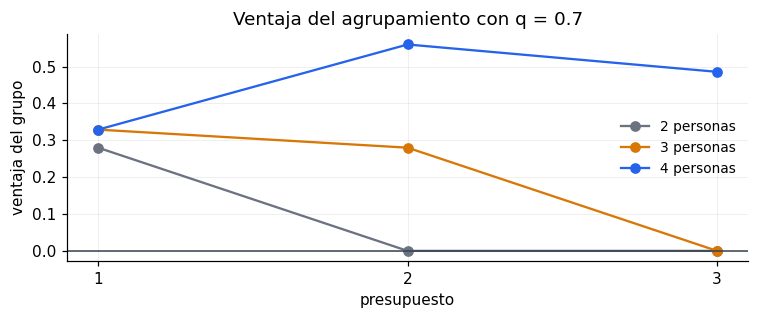

In [9]:
fig, ax = plt.subplots(figsize=(7.0, 3.0))
for m, c in zip((2, 3, 4), (GRIS, AMBAR, AZUL)):
    sub = cq[cq.personas == m]
    ax.plot(sub.presupuesto, sub['ventaja del grupo'], marker='o', color=c,
            label=f'{m} personas')
ax.axhline(0, color=TINTA, lw=1)
ax.set_xlabel('presupuesto'); ax.set_ylabel('ventaja del grupo')
ax.set_xticks([1, 2, 3]); ax.legend(frameon=False, fontsize=9)
ax.set_title('Ventaja del agrupamiento con q = 0.7')
plt.tight_layout(); plt.show()

**Lectura.** Con q = 0.7 el paso goloso ya agrupa por sí solo, así que el
problema no es que la regla de costo lo prohíba: es que el costo y el valor
cambian de orden según el presupuesto, y una regla que compare sólo valores se
equivoca en un sentido y una que compare sólo costos se equivoca en el otro.

**Para discutir.** ¿La selección debe ser una mochila —maximizar valor sujeto a
que el costo quepa— o un cociente valor sobre costo? Las dos dan políticas
distintas cuando el presupuesto es apenas suficiente.

---
## Resumen de las peticiones

| Petición | Estado |
|---|---|
| Colapso de V(T), confirmado | entregado (§6) |
| Incorporar el presupuesto restante | §7, con valor realizable exacto |
| Par valor–costo por prueba | §7 y §8, valor listo, costo con problema |
| Costo como largo esperado del árbol | §8, degenera con q < 0.5 |
| Medirlo simulando greedy | §8, implementado; greedy no agrupa en el régimen |
| Cortar el árbol en el presupuesto | §7, resuelve el colapso |
| Empezar por utilidad homogénea | todo el notebook usa u = 1 |
| Preocupación del régimen q = 0.7 | §9, confirmada y acotada |